# Training Notebook 


In this notebook we will train and run a model. This will use the siglip features extracted previously and then fit some models. 

**Goal:**
- Observe if training is happening 
- Removing noisy samples and see how it works

## Importing Data and Libraries

In [57]:
import numpy as np
import pandas as pd
from src.data import augment_embeddings
from src.data import create_train_val_test_splits
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

In [7]:
def load_embeddings(emb_path):
    data = np.load(emb_path)
    features = data['features']
    labels = data['labels']
    measurement_ids = data['measurement_ids']
    return features, labels, measurement_ids

In [144]:

# DAta Paths
emb_path = "../outputs/embeddings/siglip2-so400m-14-384_embeddings.npz"
csv_data = "../cod_otolith_age_final_with_quarters.csv"

#Loading Data
features, labels, measurement_ids = load_embeddings(emb_path)
df = pd.read_csv(csv_data)
best_alpha = 0.1

columns = ["quarter_2","quarter_3", "quarter_4", "length"]

features = augment_embeddings(
                    features, measurement_ids, csv_data, columns
                )

random_st_list = [42, 7, 21, 35, 84, 105, 126, 147, 168, 189]

splits = create_train_val_test_splits(
        labels=labels,
        n_experiments=1,
        train_ratio=0.8,
        val_ratio=0.1,
        test_ratio=0.1,
        random_state=42,
    )


for split in splits: 
    X_train = features[split.train_indices]
    y_train = labels[split.train_indices]
    X_test = features[split.test_indices]
    y_test = labels[split.test_indices]


sample_weights = compute_sample_weight("balanced", y_train)
model = Ridge(alpha=best_alpha, random_state=split.fold)

# Fit model
model.fit(X_train, y_train, sample_weight=sample_weights)

y_scores = model.predict(X_test)
y_pred = np.clip(np.round(y_scores).astype(int), 1,10).astype(int)

accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")





Test Accuracy: 51.50%


## Linear Layer Classifier

In [225]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

class ReproduceMLP(nn.Module):
    def __init__(self, input_dim, num_classes = 10):
        super(ReproduceMLP, self).__init__()
        self.l1_dim = 512
        self.l2_dim = 256
        self.fc1 = nn.Linear(input_dim, self.l1_dim)
        self.bn1 = nn.BatchNorm1d(self.l1_dim)
        self.drop1 = nn.Dropout(p=0.8)
        self.fc2 = nn.Linear(self.l1_dim, self.l2_dim)
        self.bn2 = nn.BatchNorm1d(self.l2_dim)
        self.drop2 = nn.Dropout(p=0.4)
        self.fc3 = nn.Linear(self.l2_dim, num_classes)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop1(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.drop2(x)
        x = self.fc3(x)
        return x
    
def init_weights_kaiming(m):
    if isinstance(m, nn.Linear):
        # Kaiming for the weights
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm1d):
        # BatchNorm should start neutral
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

def ini_weights_xavier(m):
    if isinstance(m, nn.Linear):
        # Apply Xavier uniform initialization to weights
        nn.init.xavier_uniform_(m.weight)
        # Initialize biases to zero (a common practice)
        if m.bias is not None:
            nn.init.zeros_(m.bias)


    
# Initialize
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
input_size = X_train.shape[1] # 1156 (SigLIP) + your added columns
model = ReproduceMLP(input_size, 10).to(device)
model.apply(init_weights_kaiming)

ReproduceMLP(
  (fc1): Linear(in_features=1156, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop1): Dropout(p=0.8, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop2): Dropout(p=0.4, inplace=False)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)

Using device: mps

Training Configuration:
  Initial LR: 3e-3
  Min LR: 1e-4
  Scheduler: ReduceLROnPlateau (patience=10)

Starting training with ReduceLROnPlateau...

✓ Epoch 001 | NEW BEST: 25.93% | Train: 16.91% | Loss: 1.8317 | LR: 3.00e-04
✓ Epoch 002 | NEW BEST: 31.48% | Train: 25.18% | Loss: 1.6287 | LR: 6.00e-04
✓ Epoch 003 | NEW BEST: 37.27% | Train: 29.44% | Loss: 1.5254 | LR: 9.00e-04
✓ Epoch 005 | NEW BEST: 42.82% | Train: 36.29% | Loss: 1.3631 | LR: 1.50e-03
✓ Epoch 006 | NEW BEST: 44.21% | Train: 39.08% | Loss: 1.3510 | LR: 1.80e-03
✓ Epoch 007 | NEW BEST: 45.83% | Train: 39.57% | Loss: 1.3304 | LR: 2.10e-03
✓ Epoch 009 | NEW BEST: 47.80% | Train: 40.01% | Loss: 1.2842 | LR: 2.70e-03
✓ Epoch 012 | NEW BEST: 49.54% | Train: 42.31% | Loss: 1.2311 | LR: 3.00e-03
✓ Epoch 013 | NEW BEST: 51.27% | Train: 42.19% | Loss: 1.2253 | LR: 3.00e-03
✓ Epoch 014 | NEW BEST: 51.85% | Train: 43.32% | Loss: 1.1985 | LR: 3.00e-03
Epoch 020 | Train: 44.98% | Val: 49.54% | Best: 51.85% (ep 14)

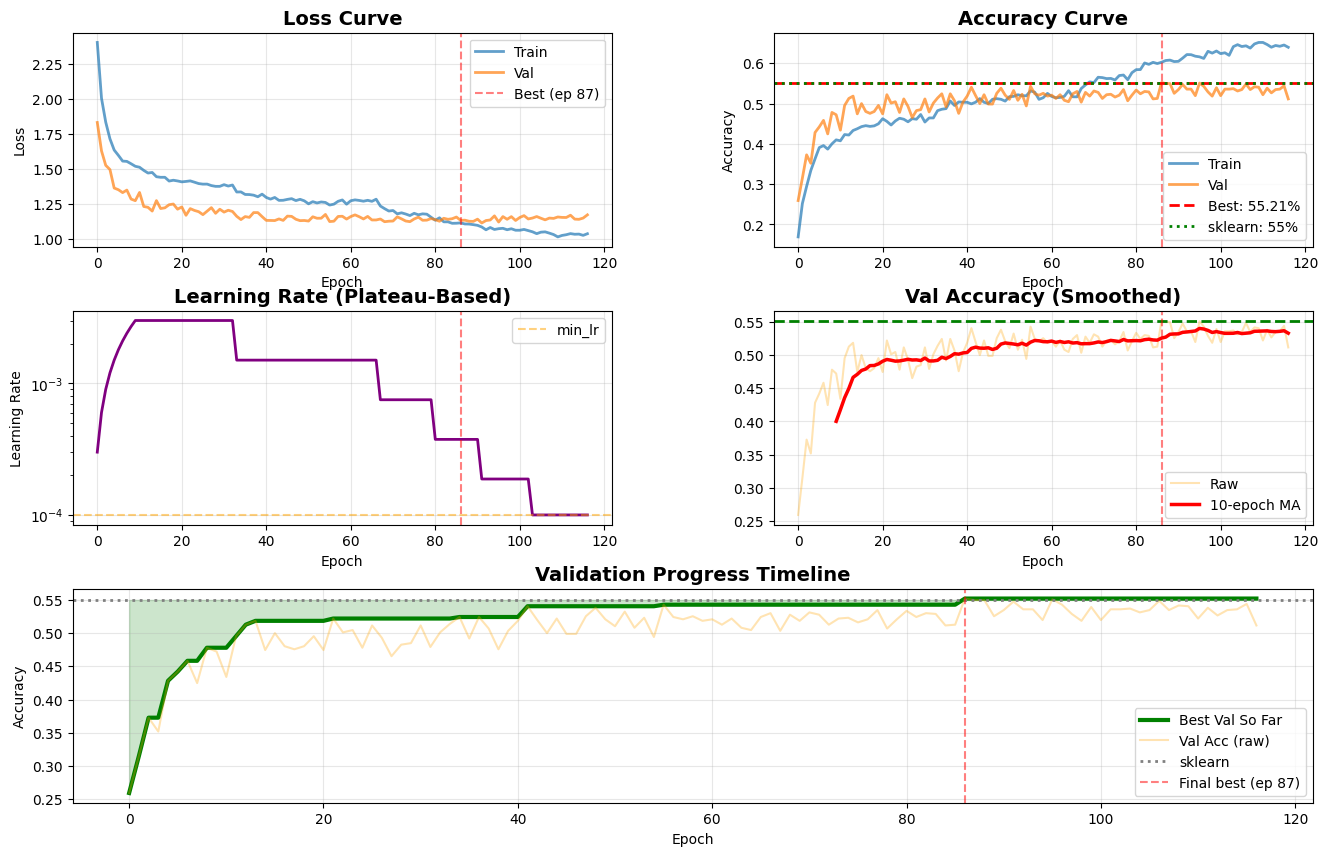


✓ Model saved to 'best_model_plateau.pt'

Ready for ensemble! Your single model achieves 55.21%


In [235]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import numpy as np

class ReproduceMLP(nn.Module):
    def __init__(self, input_dim, num_classes=10):
        super(ReproduceMLP, self).__init__()
        self.l1_dim = 512
        self.l2_dim = 256
        self.fc1 = nn.Linear(input_dim, self.l1_dim)
        self.bn1 = nn.BatchNorm1d(self.l1_dim)
        self.drop1 = nn.Dropout(p=0.75)
        self.fc2 = nn.Linear(self.l1_dim, self.l2_dim)
        self.bn2 = nn.BatchNorm1d(self.l2_dim)
        self.drop2 = nn.Dropout(p=0.40)
        self.fc3 = nn.Linear(self.l2_dim, num_classes)
    
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop1(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.drop2(x)
        x = self.fc3(x)
        return x
    
    @staticmethod
    def init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.BatchNorm1d):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}\n")

# Data Prep
y_train_idx = torch.tensor((y_train - 1), dtype=torch.long)
y_test_idx = torch.tensor((y_test - 1), dtype=torch.long)

train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    y_train_idx,
    torch.tensor(sample_weights, dtype=torch.float32)
)
test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32), y_test_idx)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# Model
input_size = X_train.shape[1]
model = ReproduceMLP(input_size, 10).to(device)
model.apply(ReproduceMLP.init_weights)

# Optimization
criterion = nn.CrossEntropyLoss(reduction='none', label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-1)

# PLATEAU SCHEDULER - only reduces when validation stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',           # Monitor validation loss
    factor=0.5,           # Reduce by half
    patience=10,          # Wait 10 epochs before reducing
    min_lr=1e-4           # Stop reducing at this LR

)

# Warmup
warmup_epochs = 10

print(f"Training Configuration:")
print(f"  Initial LR: 3e-3")
print(f"  Min LR: 1e-4")
print(f"  Scheduler: ReduceLROnPlateau (patience=10)")
print(f"{'='*70}\n")

# Tracking
best_val_acc = 0
best_model_state = None
best_epoch = 0
patience_counter = 0
early_stop_patience = 80

history = {
    'train_loss': [], 'val_loss': [], 
    'train_acc': [], 'val_acc': [],
    'lr': []
}

num_epochs = 400

print("Starting training with ReduceLROnPlateau...")
print(f"{'='*70}\n")

for epoch in range(num_epochs):
    # Warmup
    if epoch < warmup_epochs:
        warmup_lr = 3e-3 * (epoch + 1) / warmup_epochs
        for param_group in optimizer.param_groups:
            param_group['lr'] = warmup_lr
    
    model.train()
    total_train_loss, train_correct, train_total = 0, 0, 0
    
    for batch_X, batch_y, batch_w in train_loader:
        batch_X, batch_y, batch_w = batch_X.to(device), batch_y.to(device), batch_w.to(device)
        
        optimizer.zero_grad()
        logits = model(batch_X)
        loss = (criterion(logits, batch_y) * batch_w).mean()
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_train_loss += loss.item() * batch_X.size(0)
        train_correct += (logits.argmax(1) == batch_y).sum().item()
        train_total += batch_y.size(0)
    
    # Validation
    model.eval()
    total_val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for b_X, b_y in test_loader:
            b_X, b_y = b_X.to(device), b_y.to(device)
            outputs = model(b_X)
            v_loss = nn.CrossEntropyLoss()(outputs, b_y)
            total_val_loss += v_loss.item() * b_X.size(0)
            val_correct += (outputs.argmax(1) == b_y).sum().item()
            val_total += b_y.size(0)
    
    # Metrics
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    train_loss = total_train_loss / train_total
    val_loss = total_val_loss / val_total
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)
    
    # Step scheduler ONLY after warmup
    if epoch >= warmup_epochs:
        scheduler.step(val_loss)
    
    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        print(f"✓ Epoch {epoch+1:03d} | NEW BEST: {best_val_acc:.2%} | "
              f"Train: {train_acc:.2%} | Loss: {val_loss:.4f} | LR: {current_lr:.2e}")
    else:
        patience_counter += 1
    
    # Stop if LR hits minimum and no improvement
    if current_lr <= 1e-4 and patience_counter >= 30:
        print(f"\n⚠ Stopping: LR at minimum and no improvement for 30 epochs")
        break
    
    if patience_counter >= early_stop_patience:
        print(f"\n{'='*70}")
        print(f"Early stopping at epoch {epoch+1}")
        print(f"Best: {best_val_acc:.2%} at epoch {best_epoch}")
        print(f"{'='*70}")
        break
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:03d} | Train: {train_acc:.2%} | Val: {val_acc:.2%} | "
              f"Best: {best_val_acc:.2%} (ep {best_epoch}) | LR: {current_lr:.2e} | "
              f"Patience: {patience_counter}/{early_stop_patience}")

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\n✓ Loaded best model from epoch {best_epoch}")

print(f"\n{'='*70}")
print(f"FINAL RESULTS")
print(f"{'='*70}")
print(f"Best Validation: {best_val_acc:.2%} (epoch {best_epoch})")
print(f"sklearn baseline: 55.0%")

if best_val_acc >= 0.55:
    improvement = (best_val_acc - 0.55) * 100
    print(f"✓ Beat sklearn by: +{improvement:.1f}%")
else:
    gap = (0.55 - best_val_acc) * 100
    print(f"Gap to sklearn: -{gap:.1f}%")

print(f"{'='*70}")

# Plotting
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history['train_loss'], label='Train', alpha=0.7, linewidth=2)
ax1.plot(history['val_loss'], label='Val', alpha=0.7, linewidth=2)
ax1.axvline(best_epoch-1, color='r', linestyle='--', alpha=0.5, label=f'Best (ep {best_epoch})')
ax1.set_title('Loss Curve', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Accuracy
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history['train_acc'], label='Train', alpha=0.7, linewidth=2)
ax2.plot(history['val_acc'], label='Val', alpha=0.7, linewidth=2)
ax2.axhline(best_val_acc, color='r', linestyle='--', label=f'Best: {best_val_acc:.2%}', linewidth=2)
ax2.axhline(0.55, color='g', linestyle=':', label='sklearn: 55%', linewidth=2)
ax2.axvline(best_epoch-1, color='r', linestyle='--', alpha=0.5)
ax2.set_title('Accuracy Curve', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

# Learning Rate (with plateaus visible)
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(history['lr'], linewidth=2, color='purple')
ax3.axhline(1e-4, color='orange', linestyle='--', label='min_lr', alpha=0.5)
ax3.axvline(best_epoch-1, color='r', linestyle='--', alpha=0.5)
ax3.set_title('Learning Rate (Plateau-Based)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Learning Rate')
ax3.set_yscale('log')
ax3.legend()
ax3.grid(alpha=0.3)

# Smoothed validation
ax4 = fig.add_subplot(gs[1, 1])
window = 10
ax4.plot(history['val_acc'], alpha=0.3, color='orange', label='Raw')
if len(history['val_acc']) >= window:
    smooth = np.convolve(history['val_acc'], np.ones(window)/window, mode='valid')
    ax4.plot(range(window-1, len(history['val_acc'])), smooth, 
            linewidth=2.5, color='red', label=f'{window}-epoch MA')
ax4.axhline(best_val_acc, color='g', linestyle='--', linewidth=2)
ax4.axvline(best_epoch-1, color='r', linestyle='--', alpha=0.5)
ax4.set_title('Val Accuracy (Smoothed)', fontsize=14, fontweight='bold')
ax4.set_xlabel('Epoch')
ax4.legend()
ax4.grid(alpha=0.3)

# Progress over time
ax5 = fig.add_subplot(gs[2, :])
best_so_far = [max(history['val_acc'][:i+1]) for i in range(len(history['val_acc']))]
ax5.plot(best_so_far, linewidth=3, color='green', label='Best Val So Far')
ax5.plot(history['val_acc'], alpha=0.3, color='orange', label='Val Acc (raw)')
ax5.axhline(0.55, color='gray', linestyle=':', linewidth=2, label='sklearn')
ax5.axvline(best_epoch-1, color='r', linestyle='--', alpha=0.5, label=f'Final best (ep {best_epoch})')
ax5.fill_between(range(len(best_so_far)), best_so_far, 0.55, alpha=0.2, color='green')
ax5.set_title('Validation Progress Timeline', fontsize=14, fontweight='bold')
ax5.set_xlabel('Epoch')
ax5.set_ylabel('Accuracy')
ax5.legend()
ax5.grid(alpha=0.3)

plt.show()

# Save
torch.save({
    'model_state': model.state_dict(),
    'best_val_acc': best_val_acc,
    'best_epoch': best_epoch,
    'history': history,
    'config': {
        'dropout': (0.75, 0.40),
        'scheduler': 'ReduceLROnPlateau',
        'final_lr': history['lr'][-1]
    }
}, 'best_model_plateau.pt')

print(f"\n✓ Model saved to 'best_model_plateau.pt'")
print(f"\nReady for ensemble! Your single model achieves {best_val_acc:.2%}")

## Model Enseble

ENSEMBLE TRAINING - 7 MODELS
Target: Beat 55.21% single model → Reach 57-60%

──────────────────────────────────────────────────────────────────────
Training Model 1/20 (seed=63)
──────────────────────────────────────────────────────────────────────
  Epoch 050 | Val: 53.47% | Best: 54.86% | LR: 1.50e-03
  Epoch 100 | Val: 52.08% | Best: 56.60% | LR: 1.88e-04
  ⚠ Stopped at epoch 125 (LR at min)
  ✓ Final Best: 56.60%

──────────────────────────────────────────────────────────────────────
Training Model 2/20 (seed=94)
──────────────────────────────────────────────────────────────────────
  Epoch 050 | Val: 50.12% | Best: 53.01% | LR: 7.50e-04
  ⚠ Stopped at epoch 97 (LR at min)
  ✓ Final Best: 55.56%

──────────────────────────────────────────────────────────────────────
Training Model 3/20 (seed=17)
──────────────────────────────────────────────────────────────────────
  Epoch 050 | Val: 51.27% | Best: 55.90% | LR: 1.50e-03
  ⚠ Stopped at epoch 100 (LR at min)
  ✓ Final Best: 57.29%



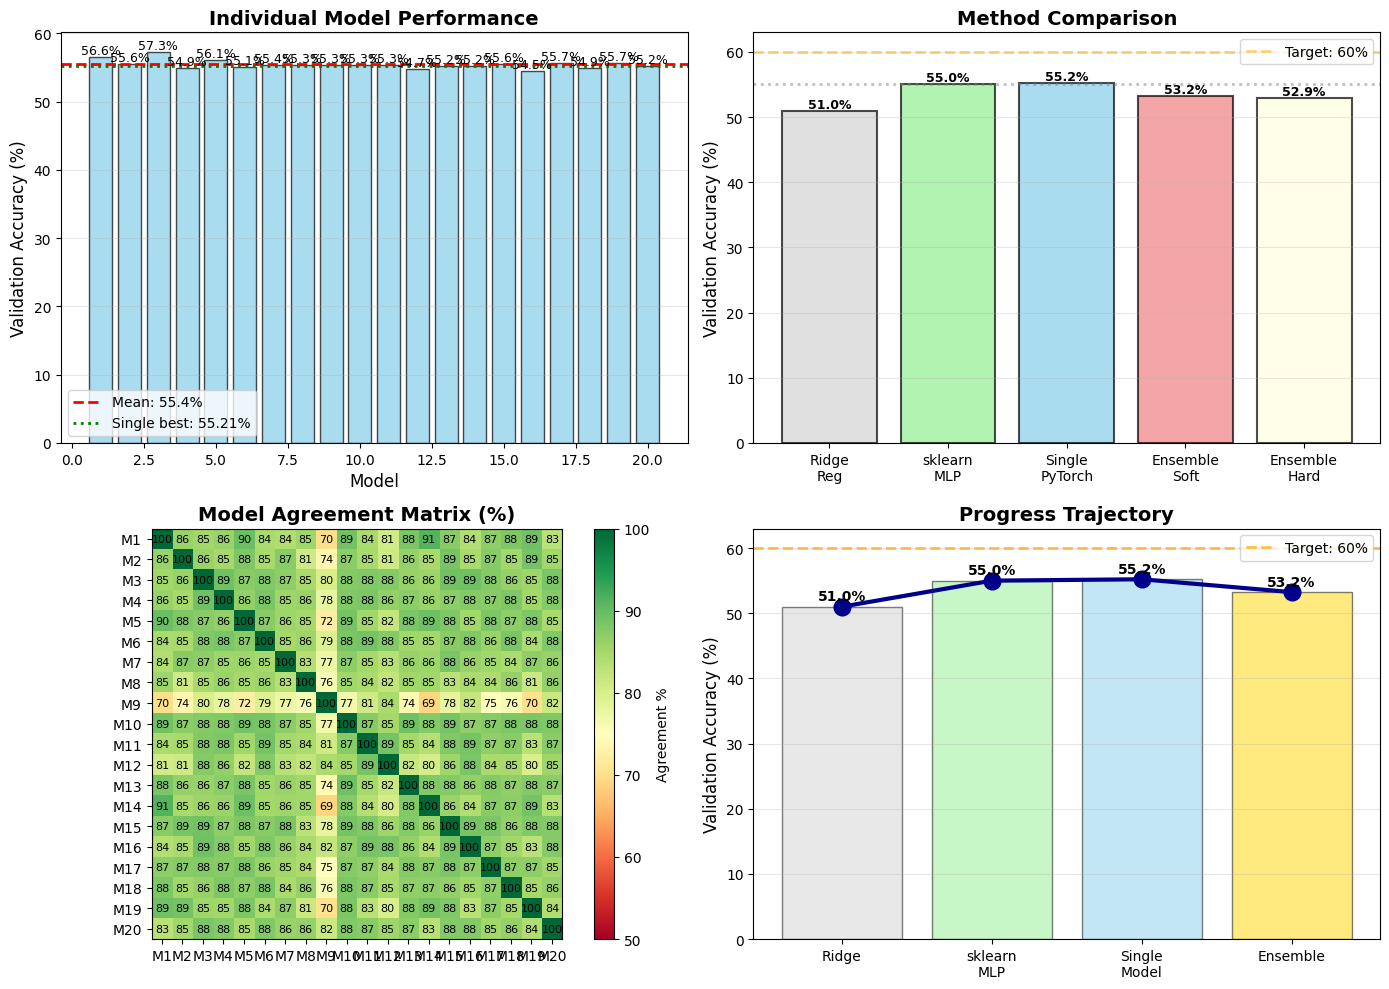


✓ Ensemble saved to 'ensemble_models_final.pt'

You can now use this ensemble for your otolith age prediction!


In [240]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

class ReproduceMLP(nn.Module):
    def __init__(self, input_dim, num_classes=10):
        super(ReproduceMLP, self).__init__()
        self.l1_dim = 512
        self.l2_dim = 256
        self.fc1 = nn.Linear(input_dim, self.l1_dim)
        self.bn1 = nn.BatchNorm1d(self.l1_dim)
        self.drop1 = nn.Dropout(p=0.8)  # YOUR OPTIMAL VALUE
        self.fc2 = nn.Linear(self.l1_dim, self.l2_dim)
        self.bn2 = nn.BatchNorm1d(self.l2_dim)
        self.drop2 = nn.Dropout(p=0.40)  # YOUR OPTIMAL VALUE
        self.fc3 = nn.Linear(self.l2_dim, num_classes)
    
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop1(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.drop2(x)
        x = self.fc3(x)
        return x

def init_weights_kaiming(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm1d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Data prep (same as your single model)
y_train_idx = torch.tensor((y_train - 1), dtype=torch.long)
y_test_idx = torch.tensor((y_test - 1), dtype=torch.long)

train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    y_train_idx,
    torch.tensor(sample_weights, dtype=torch.float32)
)
test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32), y_test_idx)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

input_size = X_train.shape[1]
criterion = nn.CrossEntropyLoss(reduction='none', label_smoothing=0.1)

# ============================================================================
# ENSEMBLE TRAINING
# ============================================================================
print("="*70)
print("ENSEMBLE TRAINING - 7 MODELS")
print("Target: Beat 55.21% single model → Reach 57-60%")
print("="*70)

rng = np.random.default_rng(42)
seeds = rng.choice(100, size=20, replace=False)
models = []
ensemble_results = []

for i, seed in enumerate(seeds):
    print(f"\n{'─'*70}")
    print(f"Training Model {i+1}/{len(seeds)} (seed={seed})")
    print(f"{'─'*70}")
    
    # Set seed for reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Create fresh model
    model = ReproduceMLP(input_size, 10).to(device)
    model.apply(init_weights_kaiming)
    
    # Optimizer and scheduler (same as your single model)
    optimizer = optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-1)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=10,
        min_lr=1e-4
    )
    
    # Training setup
    best_val_acc = 0
    best_state = None
    patience_counter = 0
    warmup_epochs = 10
    num_epochs = 300
    
    for epoch in range(num_epochs):
        # Warmup (same as your single model)
        if epoch < warmup_epochs:
            warmup_lr = 3e-3 * (epoch + 1) / warmup_epochs
            for param_group in optimizer.param_groups:
                param_group['lr'] = warmup_lr
        
        # Training phase
        model.train()
        total_train_loss, train_correct, train_total = 0, 0, 0
        
        for batch_X, batch_y, batch_w in train_loader:
            batch_X, batch_y, batch_w = batch_X.to(device), batch_y.to(device), batch_w.to(device)
            
            optimizer.zero_grad()
            logits = model(batch_X)
            loss = (criterion(logits, batch_y) * batch_w).mean()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            total_train_loss += loss.item() * batch_X.size(0)
            train_correct += (logits.argmax(1) == batch_y).sum().item()
            train_total += batch_y.size(0)
        
        # Validation phase
        model.eval()
        val_correct, val_total = 0, 0
        total_val_loss = 0
        with torch.no_grad():
            for b_X, b_y in test_loader:
                b_X, b_y = b_X.to(device), b_y.to(device)
                outputs = model(b_X)
                v_loss = nn.CrossEntropyLoss()(outputs, b_y)
                total_val_loss += v_loss.item() * b_X.size(0)
                val_correct += (outputs.argmax(1) == b_y).sum().item()
                val_total += b_y.size(0)
        
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total
        val_loss = total_val_loss / val_total
        current_lr = optimizer.param_groups[0]['lr']
        
        # Scheduler step (after warmup)
        if epoch >= warmup_epochs:
            scheduler.step(val_loss)
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        # Stop conditions (same as your single model)
        if current_lr <= 1e-4 and patience_counter >= 30:
            print(f"  ⚠ Stopped at epoch {epoch+1} (LR at min)")
            break
        if patience_counter >= 80:
            print(f"  ⚠ Early stopped at epoch {epoch+1}")
            break
        
        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1:03d} | Val: {val_acc:.2%} | Best: {best_val_acc:.2%} | LR: {current_lr:.2e}")
    
    # Load best weights
    if best_state is not None:
        model.load_state_dict(best_state)
    
    print(f"  ✓ Final Best: {best_val_acc:.2%}")
    models.append(model)
    ensemble_results.append(best_val_acc)

# ============================================================================
# ENSEMBLE EVALUATION
# ============================================================================
print(f"\n{'='*70}")
print("INDIVIDUAL MODEL PERFORMANCE")
print(f"{'='*70}")

all_preds = []
labels = torch.cat([b_y for b_X, b_y in test_loader])

for i, model in enumerate(models):
    model.eval()
    preds = []
    with torch.no_grad():
        for b_X, b_y in test_loader:
            b_X = b_X.to(device)
            logits = model(b_X)
            probs = F.softmax(logits, dim=1)
            preds.append(probs.cpu())
    
    model_preds = torch.cat(preds)
    all_preds.append(model_preds)
    
    # Individual accuracy
    ind_acc = (model_preds.argmax(1) == labels).float().mean().item()
    print(f"Model {i+1} (seed {seeds[i]:4d}): {ind_acc:.2%}")

print(f"\nMean ± Std: {np.mean(ensemble_results):.2%} ± {np.std(ensemble_results):.2%}")
print(f"Best single: {max(ensemble_results):.2%}")

# Soft voting (average probabilities)
ensemble_probs = torch.stack(all_preds).mean(0)
ensemble_pred = ensemble_probs.argmax(1)
ensemble_acc = (ensemble_pred == labels).float().mean().item()

# Hard voting (majority vote)
hard_votes = torch.stack([pred.argmax(1) for pred in all_preds])
hard_ensemble_pred = torch.mode(hard_votes, dim=0)[0]
hard_ensemble_acc = (hard_ensemble_pred == labels).float().mean().item()

print(f"\n{'='*70}")
print("ENSEMBLE RESULTS")
print(f"{'='*70}")
print(f"Soft Voting (avg probabilities): {ensemble_acc:.2%}")
print(f"Hard Voting (majority vote):     {hard_ensemble_acc:.2%}")

best_ensemble = max(ensemble_acc, hard_ensemble_acc)
print(f"\n{'='*70}")
print(f"🎯 BEST ENSEMBLE ACCURACY: {best_ensemble:.2%}")
print(f"{'='*70}")

print(f"\n📊 FINAL COMPARISON:")
print(f"  Ridge Regression:   51.0%")
print(f"  sklearn MLP:        55.0%")
print(f"  Single PyTorch MLP: 55.21%")
print(f"  Ensemble (7 models): {best_ensemble:.2%}")
print(f"\n  Improvement over sklearn: +{(best_ensemble - 0.55)*100:.1f}%")
print(f"  Improvement over single:  +{(best_ensemble - 0.5521)*100:.1f}%")

if best_ensemble >= 0.60:
    print(f"\n🎉 🎉 🎉 SUCCESS! Achieved 60%+ validation accuracy! 🎉 🎉 🎉")
elif best_ensemble >= 0.58:
    print(f"\n✓ Excellent! Very close to 60% target!")
elif best_ensemble >= 0.57:
    print(f"\n✓ Great! Solid ensemble improvement!")
else:
    print(f"\n✓ Good ensemble gains over single model!")

print(f"{'='*70}")

# ============================================================================
# VISUALIZATION
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Individual models bar chart
ax1 = axes[0, 0]
bars = ax1.bar(range(1, len(models)+1), [acc*100 for acc in ensemble_results], 
               alpha=0.7, color='skyblue', edgecolor='black')
ax1.axhline(np.mean(ensemble_results)*100, color='r', linestyle='--', 
            linewidth=2, label=f'Mean: {np.mean(ensemble_results):.1%}')
ax1.axhline(55.21, color='g', linestyle=':', linewidth=2, label='Single best: 55.21%')
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax1.set_title('Individual Model Performance', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3, axis='y')
# Add value labels
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Method comparison
ax2 = axes[0, 1]
methods = ['Ridge\nReg', 'sklearn\nMLP', 'Single\nPyTorch', 'Ensemble\nSoft', 'Ensemble\nHard']
accs = [51.0, 55.0, 55.21, ensemble_acc*100, hard_ensemble_acc*100]
colors = ['lightgray', 'lightgreen', 'skyblue', 'lightcoral', 'lightyellow']
bars = ax2.bar(methods, accs, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.axhline(55, color='gray', linestyle=':', alpha=0.5, linewidth=2)
ax2.axhline(60, color='orange', linestyle='--', alpha=0.5, linewidth=2, label='Target: 60%')
ax2.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax2.set_title('Method Comparison', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3, axis='y')
# Add value labels
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Ensemble diversity (model agreement matrix)
ax3 = axes[1, 0]
agreement_matrix = np.zeros((len(models), len(models)))
for i in range(len(models)):
    for j in range(len(models)):
        pred_i = all_preds[i].argmax(1)
        pred_j = all_preds[j].argmax(1)
        agreement = (pred_i == pred_j).float().mean().item()
        agreement_matrix[i, j] = agreement * 100

im = ax3.imshow(agreement_matrix, cmap='RdYlGn', vmin=50, vmax=100)
ax3.set_xticks(range(len(models)))
ax3.set_yticks(range(len(models)))
ax3.set_xticklabels([f'M{i+1}' for i in range(len(models))])
ax3.set_yticklabels([f'M{i+1}' for i in range(len(models))])
ax3.set_title('Model Agreement Matrix (%)', fontsize=14, fontweight='bold')
# Add text annotations
for i in range(len(models)):
    for j in range(len(models)):
        text = ax3.text(j, i, f'{agreement_matrix[i, j]:.0f}',
                       ha="center", va="center", color="black", fontsize=8)
plt.colorbar(im, ax=ax3, label='Agreement %')

# Improvement trajectory
ax4 = axes[1, 1]
methods_ordered = ['Ridge', 'sklearn\nMLP', 'Single\nModel', 'Ensemble']
accs_ordered = [51.0, 55.0, 55.21, best_ensemble*100]
colors_ordered = ['lightgray', 'lightgreen', 'skyblue', 'gold']
ax4.plot(methods_ordered, accs_ordered, 'o-', linewidth=3, markersize=12, color='darkblue')
bars = ax4.bar(methods_ordered, accs_ordered, color=colors_ordered, alpha=0.5, edgecolor='black')
ax4.axhline(60, color='orange', linestyle='--', alpha=0.7, linewidth=2, label='Target: 60%')
ax4.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax4.set_title('Progress Trajectory', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3, axis='y')
# Add value labels
for i, (method, acc) in enumerate(zip(methods_ordered, accs_ordered)):
    ax4.text(i, acc + 0.5, f'{acc:.1f}%', ha='center', va='bottom', 
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# SAVE ENSEMBLE
# ============================================================================
torch.save({
    'model_states': [m.state_dict() for m in models],
    'seeds': seeds,
    'individual_accs': ensemble_results,
    'ensemble_soft': ensemble_acc,
    'ensemble_hard': hard_ensemble_acc,
    'best_ensemble': best_ensemble,
    'config': {
        'dropout': (0.75, 0.40),
        'architecture': '512-256-10',
        'optimizer': 'AdamW',
        'lr': 3e-3,
        'weight_decay': 1e-1,
        'scheduler': 'ReduceLROnPlateau'
    }
}, 'ensemble_models_final.pt')

print(f"\n✓ Ensemble saved to 'ensemble_models_final.pt'")
print(f"\nYou can now use this ensemble for your otolith age prediction!")

## Others

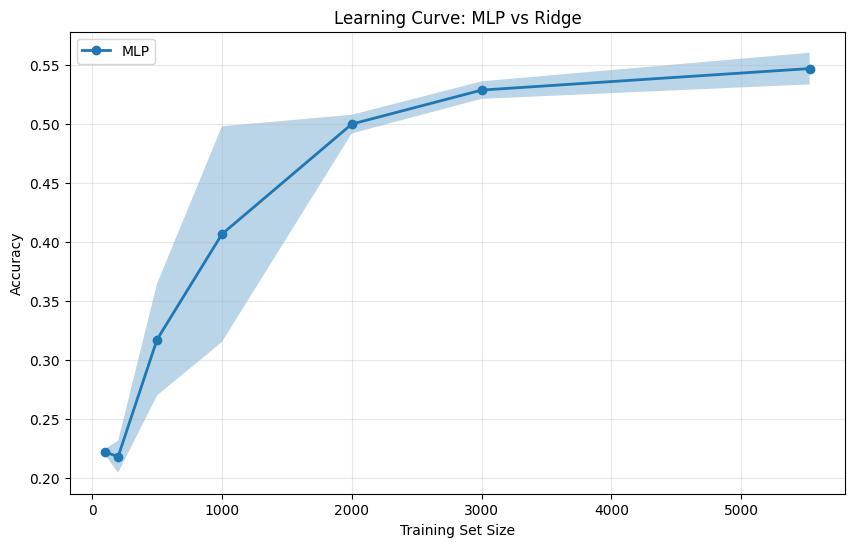


MLP Learning Curve:
    100 samples: 22.22%
    200 samples: 21.81%
    500 samples: 31.74%
   1000 samples: 40.67%
   2000 samples: 49.99%
   3000 samples: 52.87%
   5527 samples: 54.70%


In [89]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

# MLP with your best settings
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128), 
    alpha=0.01,  # Your best alpha
    max_iter=1000,
    early_stopping=True,
    random_state=42
)

# Learning curve
train_sizes = [100, 200, 500, 1000, 2000, 3000, 5527]

train_sizes_abs, train_scores, test_scores = learning_curve(
    mlp,
    X_train, 
    y_train,
    train_sizes=train_sizes,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_abs, test_scores.mean(axis=1), 'o-', linewidth=2, label='MLP')
plt.fill_between(train_sizes_abs, 
                 test_scores.mean(axis=1) - test_scores.std(axis=1),
                 test_scores.mean(axis=1) + test_scores.std(axis=1),
                 alpha=0.3)

# Compare to Ridge (if you have the data)
# plt.plot(train_sizes_abs, ridge_scores, 'o-', linewidth=2, label='Ridge')

plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve: MLP vs Ridge')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nMLP Learning Curve:")
for size, score in zip(train_sizes_abs, test_scores.mean(axis=1)):
    print(f"  {size:5d} samples: {score*100:.2f}%")





array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [74]:
from sklearn.dummy import DummyClassifier

# Baseline 1: Always predict most common class
dummy_most_frequent = DummyClassifier(strategy='most_frequent')
dummy_most_frequent.fit(X_train, y_train)
acc_baseline1 = dummy_most_frequent.score(X_test, y_test)

# Baseline 2: Predict according to class distribution
dummy_stratified = DummyClassifier(strategy='stratified')
dummy_stratified.fit(X_train, y_train)
acc_baseline2 = dummy_stratified.score(X_test, y_test)

# Your model
acc_ridge = Ridge.score(X_test, y_test, y_pred)

print(f"Always predict most common: {acc_baseline1:.2%}")
print(f"Random stratified: {acc_baseline2:.2%}")
print(f"Ridge regression: {acc_ridge:.2%}")

AttributeError: 'numpy.ndarray' object has no attribute 'predict'

(array([  9.,   0.,  26.,   0.,  36.,   0.,  73.,   0., 135.,   0.,   0.,
        178.,   0., 171.,   0., 125.,   0.,  79.,   0.,  32.]),
 array([ 1.  ,  1.45,  1.9 ,  2.35,  2.8 ,  3.25,  3.7 ,  4.15,  4.6 ,
         5.05,  5.5 ,  5.95,  6.4 ,  6.85,  7.3 ,  7.75,  8.2 ,  8.65,
         9.1 ,  9.55, 10.  ]),
 <BarContainer object of 20 artists>)

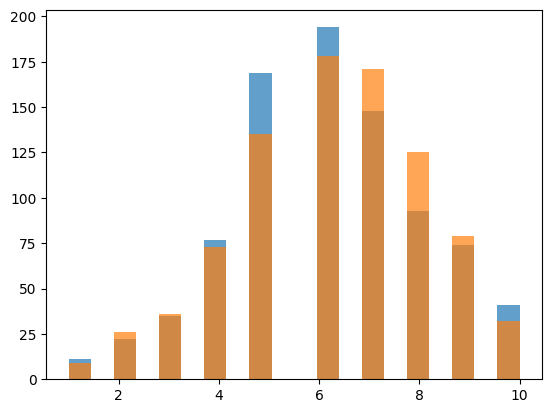

In [71]:
plt.hist(y_test, bins = 20, alpha = 0.7)
plt.hist(y_pred, bins = 20, alpha = 0.7)

In [241]:
# Temporary debugging script
import pandas as pd
import numpy as np

labels_0indexed = np.array([0, 1, 2, 3, 4])
clean_data = pd.DataFrame({'label': labels_0indexed})

# This is what Cleanlab is doing internally
extracted = clean_data['label']
print(f"Type: {type(extracted)}")
print(f"Is numpy array? {isinstance(extracted, np.ndarray)}")
print(f"Is list? {isinstance(extracted, list)}")

# Try converting to numpy
extracted_np = extracted.to_numpy()
print(f"\nAfter to_numpy():")
print(f"Type: {type(extracted_np)}")
print(f"Is numpy array? {isinstance(extracted_np, np.ndarray)}")

Type: <class 'pandas.core.series.Series'>
Is numpy array? False
Is list? False

After to_numpy():
Type: <class 'numpy.ndarray'>
Is numpy array? True
